# Plots

## Setups

In [157]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns  # optional, just for color if you like
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import statsmodels.formula.api as smf

### Setting up the dataframe

In [170]:
base_dir = "/Users/seohyon/resources/results"

# will track only these methods (above BBKNN)
keep_methods = [
    "embed_cell_types_jittered",
    "embed_cell_types",
    "shuffle_integration",
    "shuffle_integration_by_cell_type",
    "shuffle_integration",
    "scanvi",
    "combat",
    "scvi",
    "harmony",
    "harmonypy",
    "batchelor_fastmnn",
    "liger",
    "pyliger",
    "scalex",
    "uce",
    "no_integration",
    "no_integration_batch",
    "scanorama"
]

yaml_path = "/Users/seohyon/resources/results/run_2025-10-11_13-28-50/score_uns.yaml"
rows = []

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

for entry in data:
    method = entry.get("method_id", "").strip().lower()

    # keep only desired methods
    if method not in keep_methods:
        continue

    metrics = entry.get("metric_ids", [])
    values = entry.get("metric_values", [])

    for m_id, m_val in zip(metrics, values):
        rows.append({
            "dataset_id": entry.get("dataset_id"),
            "method_id": method,
            "metric_id": m_id,
            "metric_value": m_val
        })

In [171]:
df = pd.DataFrame(rows)
df = df.dropna(subset=["metric_value"]).copy() # drop NaN
# df = df[df["metric_id"] != "kbet"].copy() # drop kbet
df = df[~df["metric_id"].isin(["kbet", "hvg_overlap"])].copy() # drop unwanted metrics
df["dataset_id"] = df["dataset_id"].str.split("/").str[-1] # clean the dataset id

In [172]:
df.groupby("metric_id").size() # sanity check - do we have fair number of datapoints per metric

metric_id
ari                        102
ari_batch                  102
asw_batch                  102
asw_label                  102
cell_cycle_conservation    102
clisi                      102
graph_connectivity         102
ilisi                      102
isolated_label_asw          85
isolated_label_f1           85
kbet_pg                    102
kbet_pg_label              102
nmi                        102
nmi_batch                  102
pcr                        102
dtype: int64

In [167]:
meta = pd.read_csv("/Users/seohyon/resources/Batch_Integration_Dataset - Tabellenblatt3.csv")

df = pd.merge(df, meta, left_on="dataset_id", right_on="dataset", how="inner").drop(columns=["dataset"])

control_type_map = {
    "embed_cell_types": "positive",
    "embed_cell_types_jittered": "positive",
    "shuffle_integration": "negative",
    "shuffle_integration_by_batch": "negative",
    "shuffle_integration_by_cell_type": "negative",
    "no_integration": "baseline",
    "no_integration_batch": "baseline",
}

df["control_type"] = df["method_id"].map(control_type_map).fillna("non-control")
df["control_group"] = df["control_type"].apply(
    lambda x: "non-control method" if x == "non-control" else "control method"
)

# mapping categorical to binary for plotting
df["nested_batches_num"] = df["nested_batches"].map({"No": 0, "Yes": 1})

bio_metrics = [
    'ari',
    'nmi',
    'graph_connectivity',
    'cell_cycle_conservation',
    'asw_label',
    'isolated_label_f1',
    'isolated_label_asw',
]

batch_metrics = [
    'pcr',
    'ilisi',
    'clisi',
    'asw_batch',
    'kbet_pg',
    'kbet_pg_label',
    'ari_batch',
    'nmi_batch',
]

def categorize_metric(m):
    if m in bio_metrics:
        return "bio"
    if m in batch_metrics:
        return "batch"
    return "baseline"

df["metric_type"] = df["metric_id"].apply(categorize_metric)

In [168]:
baseline = df[df["metric_type"] == "baseline"]
non_baseline = df[df["metric_type"] != "baseline"]

# For non-baseline, the metric_group is just metric_type ("bio" or "batch")
non_baseline = non_baseline.assign(metric_group=non_baseline["metric_type"])

# Duplicate baseline rows: one copy for "bio", one for "batch"
baseline_bio = baseline.copy()
baseline_bio["metric_group"] = "bio"

baseline_batch = baseline.copy()
baseline_batch["metric_group"] = "batch"

# Combine everything
df = pd.concat(
    [non_baseline, baseline_bio, baseline_batch],
    ignore_index=True
)

In [169]:
df.groupby("metric_id").size() # sanity check - do we have fair number of datapoints per metric

metric_id
ari                        102
ari_batch                  102
asw_batch                  102
asw_label                  102
cell_cycle_conservation    102
clisi                      102
graph_connectivity         102
ilisi                      102
isolated_label_asw          85
isolated_label_f1           85
kbet_pg                    102
kbet_pg_label              102
nmi                        102
nmi_batch                  102
pcr                        102
dtype: int64

In [163]:
df.groupby(["metric_id", "method_id"]).size().unique()


array([6, 5])

In [164]:
df.query("metric_id == 'ari'").groupby("method_id").size()

method_id
batchelor_fastmnn                   6
combat                              6
embed_cell_types                    6
embed_cell_types_jittered           6
harmony                             6
harmonypy                           6
liger                               6
no_integration                      6
no_integration_batch                6
pyliger                             6
scalex                              6
scanorama                           6
scanvi                              6
scvi                                6
shuffle_integration                 6
shuffle_integration_by_cell_type    6
uce                                 6
dtype: int64

In [165]:
df.query("metric_id == 'isolated_label_asw'").groupby("method_id").size()

method_id
batchelor_fastmnn                   5
combat                              5
embed_cell_types                    5
embed_cell_types_jittered           5
harmony                             5
harmonypy                           5
liger                               5
no_integration                      5
no_integration_batch                5
pyliger                             5
scalex                              5
scanorama                           5
scanvi                              5
scvi                                5
shuffle_integration                 5
shuffle_integration_by_cell_type    5
uce                                 5
dtype: int64

### Helper functions for plotting

In [4]:
# might not be used in this nb

# For each integration method, does this dataset feature (e.g. n_genes, size, batch imbalance…) have a monotone relationship with the method's metric values?
def spearman_by_method(df_metric, feature, plot=True, save="", palette="viridis"):
    correlations = []

    for method in df_metric["method_id"].unique():
        df_m = df_metric[df_metric["method_id"] == method]

        if len(df_m) < 2:
            continue

        # Drop NaNs only for the correlation calculation
        valid = df_m[[feature, "metric_value"]].dropna()

        if len(valid) < 2:
            rho, pval = np.nan, np.nan
        else:
            rho, pval = spearmanr(valid[feature], valid["metric_value"])

        correlations.append({
            "method": method,
            "spearman_rho": rho,
            "p_value": pval,
            "n_points": len(df_m),
            "control_group": df_m.loc[df_m["method_id"] == method, "control_group"].iloc[0]
        })

    corr_df = pd.DataFrame(correlations).sort_values("spearman_rho", ascending=False)

    # ---------- PLOT ----------
    if plot and not corr_df.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=corr_df,
            x="spearman_rho",
            y="method",
            orient="h",
            hue="control_group",
        )
        plt.axvline(0, color="black", linewidth=1)
        plt.title(f"Method-level spearman correlation: metric_value vs {feature}")
        plt.xlabel("Spearman ρ")
        plt.ylabel("Method")
        plt.tight_layout()  
        
        if save != "":
            plt.savefig(f"/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/{save}.png", dpi=300, bbox_inches='tight')
            
        plt.show()

    return corr_df

# For each evaluation metric (ARI, NMI, kBET, ASW, etc.), does this dataset feature show a monotone relationship with metric values?
def spearman_by_metric(df_metric, feature, plot=True, save="", palette="tab10"):
    correlations = []

    for metric in df_metric["metric_id"].unique():
        df_m = df_metric[df_metric["metric_id"] == metric]

        # Drop NaNs only for correlation
        valid = df_m[[feature, "metric_value"]].dropna()
        if len(valid) < 2:
            rho, pval = np.nan, np.nan
        else:
            rho, pval = spearmanr(valid[feature], valid["metric_value"])

        correlations.append({
            "metric_id": metric,
            "spearman_rho": rho,
            "p_value": pval,
            "n_points": len(df_m),
            # if your df has this:
            "metric_type": df_m["metric_type"].iloc[0] if "metric_type" in df_m else None,
            "feature": feature,
        })

    corr_df = pd.DataFrame(correlations).sort_values("spearman_rho", ascending=False)
        
    if plot and not corr_df.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=corr_df,
            x="spearman_rho",
            y="metric_id",
            orient="h",
            hue="metric_type" if "metric_type" in corr_df else None,
            palette=palette
        )
        plt.axvline(0, color="black", linewidth=1)
        plt.title(f"Metric-level spearman correlation: metric_value vs {feature}")
        plt.xlabel("Spearman ρ")
        plt.ylabel("Metric")
        plt.tight_layout()
        
        if save != "":
            plt.savefig(f"/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/{save}.png", dpi=300, bbox_inches='tight')

        plt.show()
        
    return corr_df

def spearman_by_metric_multi(df_metric, features, n_cols=3, height=4, save=""):
    dfs = []
    for feat in features:
        corr_df = spearman_by_metric(df_metric, feat, plot=False, save=False)
        dfs.append(corr_df)

    df_all = pd.concat(dfs, ignore_index=True)

    # Alphabetical ordering
    all_metrics = sorted(df_all["metric_id"].unique())

    n_features = len(features)
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, height * n_rows),
        squeeze=False
    )

    for i, feat in enumerate(features):
        r = i // n_cols
        c = i % n_cols
        ax = axes[r, c]

        df_feat = df_all[df_all["feature"] == feat].copy()
        df_feat = df_feat.sort_values("metric_id")

        sns.barplot(
            data=df_feat,
            y="metric_id",
            x="spearman_rho",
            order=all_metrics,
            hue="metric_id",        # <–– required to allow palette
            palette="tab20",
            legend=False,           # <–– hides the hue legend
            orient="h",
            ax=ax,
        )

        ax.axvline(0, color="grey", lw=1)
        ax.set_title(feat)
        ax.set_xlabel("Spearman ρ")
        ax.set_ylabel("Metric")

    # Hide empty axes
    for j in range(i + 1, n_rows * n_cols):
        r = j // n_cols
        c = j % n_cols
        axes[r, c].set_visible(False)

    plt.tight_layout()
        
    if save != "":
        plt.savefig(f"/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/{save}.png", dpi=300, bbox_inches='tight')

    plt.show()

    return df_all

In [30]:
# different points per method -> error bar
def spearman_per_metric_across_methods(df, feature, palette="tab20", save=""):
    """
    For a given feature column, compute Spearman(feature, metric_value)
    for each metric_id × method_id pair, then plot a pointplot:

      x-axis: metric_id
      y-axis: Spearman rho across methods
      error bars: SD across methods
      faceted by: metric_type (bio / batch / baseline)

    Assumes df has columns:
      - metric_id
      - method_id
      - metric_value
      - <feature> (name passed as `feature`)
      - metric_type (for faceting)
    """
    rows = []

    # ----- compute rho per metric × method -----
    for metric in df["metric_id"].unique():
        df_metric = df[df["metric_id"] == metric]

        for method in df_metric["method_id"].unique():
            df_mm = df_metric[df_metric["method_id"] == method][[feature, "metric_value"]].dropna()

            # need at least 2 points
            if len(df_mm) < 2:
                continue

            # skip constant inputs (Spearman undefined)
            if df_mm[feature].nunique() < 2 or df_mm["metric_value"].nunique() < 2:
                continue

            rho, _ = spearmanr(df_mm[feature], df_mm["metric_value"])

            rows.append({
                "metric_id": metric,
                "method_id": method,
                "spearman_rho": rho,
                "metric_type": df_metric["metric_type"].iloc[0]
                    if "metric_type" in df_metric
                    else None
            })

    corr = pd.DataFrame(rows)

    if corr.empty:
        print("No valid correlations (all constant inputs or too few points).")
        return None

    summary = (
        corr.groupby(["metric_id", "metric_type"])["spearman_rho"]
            .agg(["mean", "std", "count"])
            .reset_index()
            .sort_values("mean", ascending=False)
    )

    # ----- FACETTED PLOT: one column per metric_type -----
    g = sns.catplot(
        data=corr,
        kind="point",
        x="metric_id",
        y="spearman_rho",
        col="metric_type",
        errorbar="sd",      # SD across methods
        dodge=True,
        linestyles="none",
        height=4,
        aspect=1.2,
        sharey=True,
        # palette=palette,  # only used if you add a hue
    )

    # Horizontal zero line in each facet
    for ax in g.axes.flatten():
        ax.axhline(0, color="black", lw=1)
        ax.set_xlabel("Metric")
        ax.set_ylabel("Spearman ρ")

        # Rotate x-tick labels for readability
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment("right")

    g.fig.suptitle(
        f"Metric-level Spearman correlation with {feature}\n"
        "(per-method correlations, SD across methods)",
        y=1.02
    )
    g.fig.tight_layout()

    if save != "":
        g.fig.savefig(
            f"/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/{save}.png",
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

    return summary, corr


In [152]:
def metric_vs_feature_by_method_facet(
    df,
    feature,
    title="",
    metric_col="metric_id",
    y_col="metric_value",
    height=3.2,
    col_wrap=4,
    sharex=True,
    sharey=False,
    save="",
):
    """
    Facet by metric, hue by method, using FacetGrid + regplot.
    Includes correct legend with color + linestyle.
    """

    if df.empty:
        print(f"[plot_metric_vs_feature_by_method_facet] No data to plot for: {title}")
        return

    if feature not in df.columns:
        raise ValueError(f"Feature '{feature}' not in dataframe columns.")

    # Consistent ordering
    metric_order = sorted(df[metric_col].unique())
    method_order = sorted(df["method_id"].unique())

    # Assign colors and linestyles
    palette = sns.color_palette("husl", n_colors=len(method_order))

    line_styles = ["-", "--", ":", "-."]

    method_to_color = dict(zip(method_order, palette))
    method_to_style = {
        m: line_styles[i % len(line_styles)] for i, m in enumerate(method_order)
    }

    # FacetGrid (hue is defined but regplot ignores it; we use for mapping)
    g = sns.FacetGrid(
        df,
        col=metric_col,
        hue="method_id",
        col_wrap=col_wrap,
        height=height,
        col_order=metric_order,
        hue_order=method_order,
        sharex=sharex,
        sharey=sharey,
    )

    # Plot function using manual color + linestyle
    def reg_with_style(data, color, **kwargs):
        method = data["method_id"].iloc[0]
        style = method_to_style[method]

        sns.regplot(
            data=data,
            x=feature,
            y=y_col,
            ci=None,
            scatter=True,
            color=method_to_color[method],
            scatter_kws={"s": 20, "alpha": 0.6},
            line_kws={"linewidth": 1.5, "linestyle": style},
        )

    g.map_dataframe(reg_with_style)

    # --------- LEGEND (manual color + line style) ----------
    handles = [
        Line2D(
            [0], [0],
            color=method_to_color[m],
            linestyle=method_to_style[m],
            linewidth=2,
            marker="o",
            markersize=5,
            label=m,
        )
        for m in method_order
    ]

    g.add_legend(handles=handles, title="method_id")

    # Labels & titles
    g.set_axis_labels(feature, y_col)
    g.set_titles(col_template="{col_name}")
    g.fig.subplots_adjust(top=0.9)
    if title:
        g.fig.suptitle(title, y=1.02)
        
    if save != "":
        plt.savefig(f"/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/{save}.png", dpi=300, bbox_inches='tight')

    plt.show()

In [81]:
def overall_for_feature(
    df,
    feature,
    title="",
    save="",
):


    control_type_order = ["positive", "negative", "baseline", "non-control"]

    # Palette for control types (method types)
    palette_ct = dict(
        zip(
            control_type_order,
            sns.color_palette("tab10", n_colors=len(control_type_order))
        )
    )

    g = sns.FacetGrid(
        df,
        row="metric_group",      # <-- facet by metric_group (bio vs batch)
        hue="control_type",      # <-- color by method type
        height=4,
        palette=palette_ct,
        row_order=["bio", "batch"],
        hue_order=control_type_order,
        sharex=True,
        sharey=True,
    )

    line_styles = ["-", "--", ":", "-."]  # whatever you already use

    def reg_with_style(data, color, **kwargs):
        # one line per method_id inside this facet & hue
        for i, (method, df_m) in enumerate(data.groupby("method_id")):
            style = line_styles[i % len(line_styles)]
            sns.regplot(
                data=df_m,
                x=feature,
                y="metric_value",
                color=color,      # color = control_type
                ci=None,
                scatter=True,
                line_kws={"linestyle": style, "linewidth": 2},
                **kwargs
            )

    g.map_dataframe(reg_with_style)

    # Legend now shows control_type
    g.add_legend(title="Control type")

    g.set_axis_labels(f"{feature}", "Metric value")
    g.fig.subplots_adjust(hspace=0.3)

    if title:
        g.fig.suptitle(title, y=1.02)
        
    if save != "":
        plt.savefig(f"/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/{save}.png", dpi=300, bbox_inches='tight')
        # e.g. <feature_overall>        

### Linear Mixed Effects Models

- fixed effect: feature (slope you care about)
- random effect: method (nuisance variability, partial pooling)
- optionally random slope: method-specific deviation from the global slope

- actually do NOT do linear mixed effects model - use simpler model

In [138]:
# these aggregates for metric id so these are bs
def fit_random_intercept_model(
    df,
    feature="size",
    metric_col="metric_value",
    method_col="method_id",
    reml=True,
):
    """
    Fit a mixed-effects model with a random intercept for method:

        metric_col ~ feature + (1 | method_col)
    """
    formula = f"{metric_col} ~ {feature}"

    model = smf.mixedlm(
        formula=formula,
        data=df,
        groups=df[method_col],
        re_formula="~1",   # random intercept only
    )

    fit = model.fit(reml=reml)
    return fit, fit.summary()



def fit_random_slope_model(df, feature, 
                           metric_col="metric_value", 
                           method_col="method_id"):
    """
    Fits a mixed-effects model with random intercept and random slope:
    
        metric_value ~ feature + (feature | method_id)
    
    Returns:
        model_fit: fitted statsmodels object
        summary: model summary table
    """

    formula = f"{metric_col} ~ {feature}"
    
    # Random effects formula "~ feature" means random intercept + random slope
    model = smf.mixedlm(
        formula=formula,
        data=df,
        groups=df[method_col],
        re_formula=f"~{feature}"
    )

    fit = model.fit(reml=True) # Restricted Maximum Likelihood (REML) - standard for linear mixed effects model

    return fit, fit.summary()

In [74]:
def fit_model(
    df,
    feature,
    metric_col="metric_value",
    metric_id_col="metric_id",
    method_col="method_id"
):
    """
    For each metric:
      1. Try random intercept + random slope model:
            metric ~ feature + (feature | method)
      2. If it fails or slope variance is zero, fallback to:
            metric ~ feature + (1 | method)

    Returns tidy dataframe with:
        metric_id, beta_feature, p_value, model_type, slope_var, intercept_var
    """

    results = []

    for metric in df[metric_id_col].unique():
        df_m = df[df[metric_id_col] == metric]

        # --- try random slope model ---
        slope_model = smf.mixedlm(
            f"{metric_col} ~ {feature}",
            df_m,
            groups=df_m[method_col],
            re_formula=f"~{feature}"
        )

        try:
            slope_fit = slope_model.fit(reml=True)
            converged = slope_fit.converged
        except:
            converged = False
        
        # Check if random slope variance is > 0
        valid_slope = False
        if converged:
            try:
                slope_var = slope_fit.cov_re.iloc[1,1]
                if slope_var > 1e-9:
                    valid_slope = True
                else:
                    valid_slope = False
            except:
                valid_slope = False

        # --- If valid, keep the random slope model ---
        if valid_slope:
            fit = slope_fit
            model_type = "random_slope"
        else:
            # fallback to random intercept
            intercept_model = smf.mixedlm(
                f"{metric_col} ~ {feature}",
                df_m,
                groups=df_m[method_col],
                re_formula="~1"
            )
            fit = intercept_model.fit(reml=True)
            model_type = "random_intercept"

        # Extract fixed effect slope
        beta = fit.fe_params.get(feature, float("nan"))
        pval = fit.pvalues.get(feature, float("nan"))

        # Extract random effect variances
        try:
            intercept_var = fit.cov_re.iloc[0,0]
        except:
            intercept_var = float("nan")

        try:
            slope_var = fit.cov_re.iloc[1,1] if model_type == "random_slope" else 0.0
        except:
            slope_var = 0.0

        # check if this is a statistical thing..
        feature_range = df_m[feature].max() - df_m[feature].min()
        practical_effect = beta * feature_range

        results.append({
            "metric_id": metric,
            "model_type": model_type,
            "beta_feature": beta,
            "p_value": pval,
            "intercept_var": intercept_var,
            "slope_var": slope_var,
            "practical_effect": practical_effect

        })

    return pd.DataFrame(results)


In [109]:
# in case slope_var exists
def extract_method_slopes(fit, feature):
    """
    fit = mixedlm fit result
    feature = name of feature with random slope (e.g. "n_tissues")

    Returns a dataframe with:
        method_id, slope, intercept_shift, slope_shift
    """

    fixed_slope = fit.fe_params[feature]
    
    rows = []
    for method, params in fit.random_effects.items():
        # params contains both intercept and slope shift
        slope_shift = params.get(feature, 0.0)
        method_slope = fixed_slope + slope_shift

        rows.append({
            "method_id": method,
            "slope": method_slope,
            "slope_shift": slope_shift,
            "intercept_shift": params.get("Intercept", 0.0)
        })

    return pd.DataFrame(rows)


In [90]:
def fit_model_binary(
    df,
    binary_feature,             # e.g. "nested_batches" or "organism"
    metric_col="metric_value",
    metric_id_col="metric_id",
    method_col="method_id",
):
    """
    For each metric:
        metric ~ C(binary_feature) + (1 | method)

    Returns:
        metric_id, beta_diff, p_value, intercept_var, resid_var
    """
    results = []

    for metric in df[metric_id_col].unique():
        df_m = df[df[metric_id_col] == metric]

        model = smf.mixedlm(
            f"{metric_col} ~ C({binary_feature})",
            df_m,
            groups=df_m[method_col],
            re_formula="~1",
        )
        fit = model.fit(reml=True)

        # term name like C(nested_batches)[T.Yes] or C(organism)[T.Mouse]
        levels = df_m[binary_feature].unique().tolist()
        levels = [lvl for lvl in levels if lvl is not None]

        # statsmodels picks one as reference; we grab the non-reference
        term = [t for t in fit.fe_params.index if t.startswith(f"C({binary_feature})")][0]

        beta = fit.fe_params.get(term, float("nan"))
        pval = fit.pvalues.get(term, float("nan"))
        intercept_var = fit.cov_re.iloc[0, 0]
        resid_var = fit.scale

        results.append({
            "metric_id": metric,
            "binary_feature": binary_feature,
            "contrast_term": term,
            "beta_diff": beta,         # difference (level vs reference)
            "p_value": pval,
            "intercept_var": intercept_var,
            "resid_var": resid_var,
        })

    return pd.DataFrame(results)


In [69]:
df

,dataset_id,method_id,metric_id,metric_value,organism,n_tissues,size,n_genes,n_celltypes,n_batches,batch_imbalance_cv,batch_imbalance_gc,nested_batches,n_samples,n_donors,control_type,control_group,nested_batches_num,metric_type,metric_group
0,gtex_v9,embed_cell_types,ilisi,0.116225,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,positive,control method,1,batch,batch
1,gtex_v9,embed_cell_types,clisi,1.000000,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,positive,control method,1,batch,batch
2,hypomap,batchelor_fastmnn,ilisi,0.000518,Mouse,1,384925,51216,13,24,4.40,0.908038,No,126.0,24,non-control,non-control method,0,batch,batch
3,hypomap,batchelor_fastmnn,clisi,1.000000,Mouse,1,384925,51216,13,24,4.40,0.908038,No,126.0,24,non-control,non-control method,0,batch,batch
4,mouse_pancreas_atlas,embed_cell_types_jittered,cell_cycle_conservation,0.681843,Mouse,1,301796,31202,20,56,0.66,0.354691,Yes,56.0,56,positive,control method,1,bio,bio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1491,tabula_sapiens,pyliger,ari_batch,0.960975,Human,75,1136218,60606,180,24,1.35,0.642039,No,658.0,24,non-control,non-control method,0,batch,batch
1492,tabula_sapiens,pyliger,nmi_batch,0.886413,Human,75,1136218,60606,180,24,1.35,0.642039,No,658.0,24,non-control,non-control method,0,batch,batch
1493,immune_cell_atlas,embed_cell_types_jittered,kbet_pg,0.274452,Human,17,329762,35469,35,12,0.96,0.460000,No,NaN,12,positive,control method,0,batch,batch
1494,gtex_v9,scalex,isolated_label_f1,0.016119,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,non-control,non-control method,1,bio,bio


## vs Size

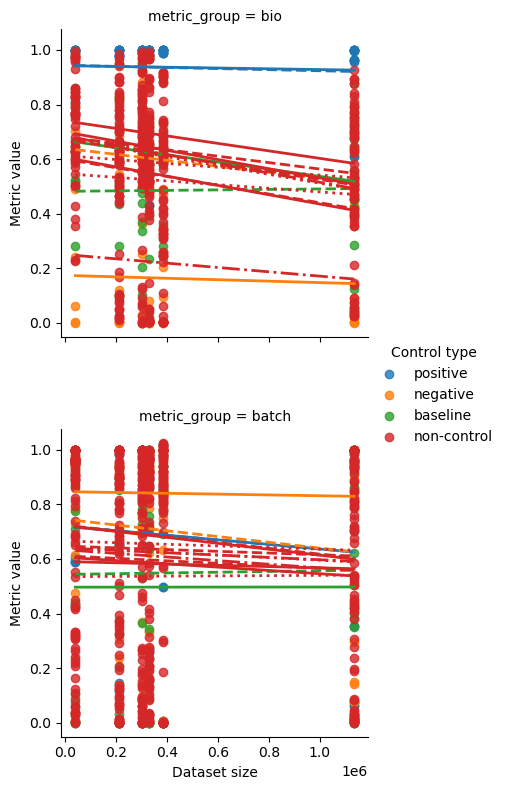

In [14]:
overall_for_feature(df, "size")

- bio-metrics shows negative slope for the most
- batch-metrics: negative control method actually scored better?
     -> makes sense: shuffle integration is mixing everything completely randomly - which is expected to remove the batch effect well, but biological information might be gone 

In [49]:
df.query("control_type == 'negative' and metric_group == 'batch'").sort_values("metric_value", ascending=False).head(20)


,dataset_id,method_id,metric_id,metric_value,organism,n_tissues,size,n_genes,n_celltypes,n_batches,batch_imbalance_cv,batch_imbalance_gc,nested_batches,n_samples,n_donors,control_type,control_group,nested_batches_num,metric_type,metric_group
233,hypomap,shuffle_integration_by_cell_type,ari_batch,1.001508,Mouse,1,384925,51216,13,24,4.40,0.908038,No,126.0,24,negative,control method,0,batch,batch
1209,immune_cell_atlas,shuffle_integration,ari_batch,1.000173,Human,17,329762,35469,35,12,0.96,0.460000,No,NaN,12,negative,control method,0,batch,batch
1374,tabula_sapiens,shuffle_integration,ari_batch,1.000077,Human,75,1136218,60606,180,24,1.35,0.642039,No,658.0,24,negative,control method,0,batch,batch
1359,hypomap,shuffle_integration,ari_batch,1.000045,Mouse,1,384925,51216,13,24,4.40,0.908038,No,126.0,24,negative,control method,0,batch,batch
1110,mouse_pancreas_atlas,shuffle_integration,ari_batch,1.000021,Mouse,1,301796,31202,20,56,0.66,0.354691,Yes,56.0,56,negative,control method,1,batch,batch
371,gtex_v9,shuffle_integration,ari_batch,1.000020,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,negative,control method,1,batch,batch
617,hypomap,shuffle_integration_by_cell_type,clisi,1.000000,Mouse,1,384925,51216,13,24,4.40,0.908038,No,126.0,24,negative,control method,0,batch,batch
510,mouse_pancreas_atlas,shuffle_integration_by_cell_type,clisi,1.000000,Mouse,1,301796,31202,20,56,0.66,0.354691,Yes,56.0,56,negative,control method,1,batch,batch
989,dkd,shuffle_integration,ari_batch,0.999958,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,negative,control method,0,batch,batch
1362,dkd,shuffle_integration_by_cell_type,clisi,0.999806,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,negative,control method,0,batch,batch


In [46]:
df.query("method_id == 'shuffle_integration_batch'").sort_values("metric_value", ascending=False).head(10)

,dataset_id,method_id,metric_id,metric_value,organism,n_tissues,size,n_genes,n_celltypes,n_batches,batch_imbalance_cv,batch_imbalance_gc,nested_batches,n_samples,n_donors,control_type,control_group,nested_batches_num,metric_type,metric_group


In [52]:
df.query("control_type == 'negative' and metric_group == 'batch' and (metric_id == 'kbet_pg' or metric_id == 'kbet_pg_label')").sort_values("metric_value", ascending=False).head(10)

,dataset_id,method_id,metric_id,metric_value,organism,n_tissues,size,n_genes,n_celltypes,n_batches,batch_imbalance_cv,batch_imbalance_gc,nested_batches,n_samples,n_donors,control_type,control_group,nested_batches_num,metric_type,metric_group
910,dkd,shuffle_integration,kbet_pg,0.951297,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,negative,control method,0,batch,batch
1090,dkd,shuffle_integration_by_cell_type,kbet_pg_label,0.950398,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,negative,control method,0,batch,batch
366,dkd,shuffle_integration,kbet_pg_label,0.940445,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,negative,control method,0,batch,batch
129,immune_cell_atlas,shuffle_integration,kbet_pg,0.940175,Human,17,329762,35469,35,12,0.96,0.460000,No,NaN,12,negative,control method,0,batch,batch
143,gtex_v9,shuffle_integration,kbet_pg_label,0.934663,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,negative,control method,1,batch,batch
750,tabula_sapiens,shuffle_integration,kbet_pg_label,0.934642,Human,75,1136218,60606,180,24,1.35,0.642039,No,658.0,24,negative,control method,0,batch,batch
1182,gtex_v9,shuffle_integration_by_cell_type,kbet_pg_label,0.934097,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,negative,control method,1,batch,batch
1161,tabula_sapiens,shuffle_integration_by_cell_type,kbet_pg_label,0.933650,Human,75,1136218,60606,180,24,1.35,0.642039,No,658.0,24,negative,control method,0,batch,batch
417,gtex_v9,shuffle_integration,kbet_pg,0.933633,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,negative,control method,1,batch,batch
269,immune_cell_atlas,shuffle_integration,kbet_pg_label,0.924293,Human,17,329762,35469,35,12,0.96,0.460000,No,NaN,12,negative,control method,0,batch,batch


- shuffle_integration_by_cell_type and shuffle_integration are both randomized. Why so high with batch-metric?

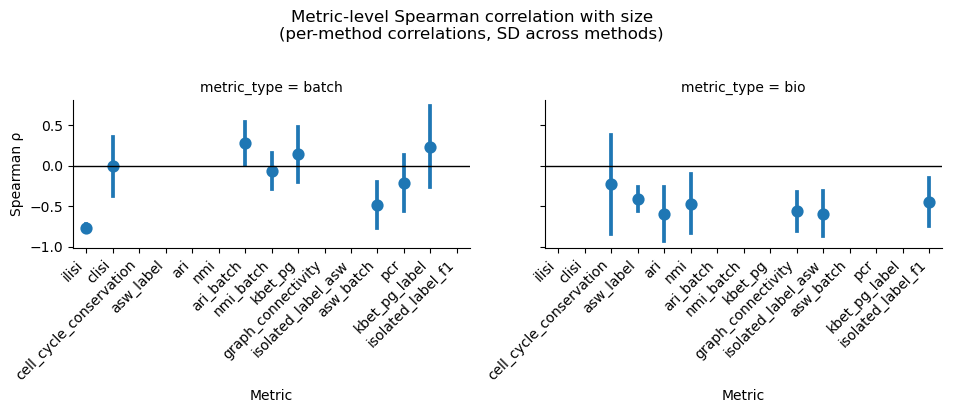

(                  metric_id metric_type      mean       std  count
 1                 ari_batch       batch  0.277311  0.263370     17
 11            kbet_pg_label       batch  0.233613  0.499820     17
 10                  kbet_pg       batch  0.144114  0.336586     17
 5                     clisi       batch -0.004324  0.361017     15
 13                nmi_batch       batch -0.065546  0.219407     17
 14                      pcr       batch -0.215132  0.345480     17
 4   cell_cycle_conservation         bio -0.226891  0.614159     17
 3                 asw_label         bio -0.408403  0.153784     17
 9         isolated_label_f1         bio -0.442013  0.298813     17
 12                      nmi         bio -0.466225  0.367379     17
 2                 asw_batch       batch -0.478992  0.284198     17
 6        graph_connectivity         bio -0.559371  0.239573     17
 8        isolated_label_asw         bio -0.588235  0.280362     17
 0                       ari         bio -0.5963

In [32]:
spearman_per_metric_across_methods(df,
                                   "size",
                                   #save="metric_vs_size_by_method_metric_type",
                                  )

- shuffle_integration & shuffle_integration_by_cell_type are both negative (radomized) control-methods and they have very high score (over 0.9) with the batch-metrics (clisi, ari_batch, nmi_batch, kbet_pg, kbet_pg_label) that show positive correlation against the trend.
    - why? should I exclude them from modeling?

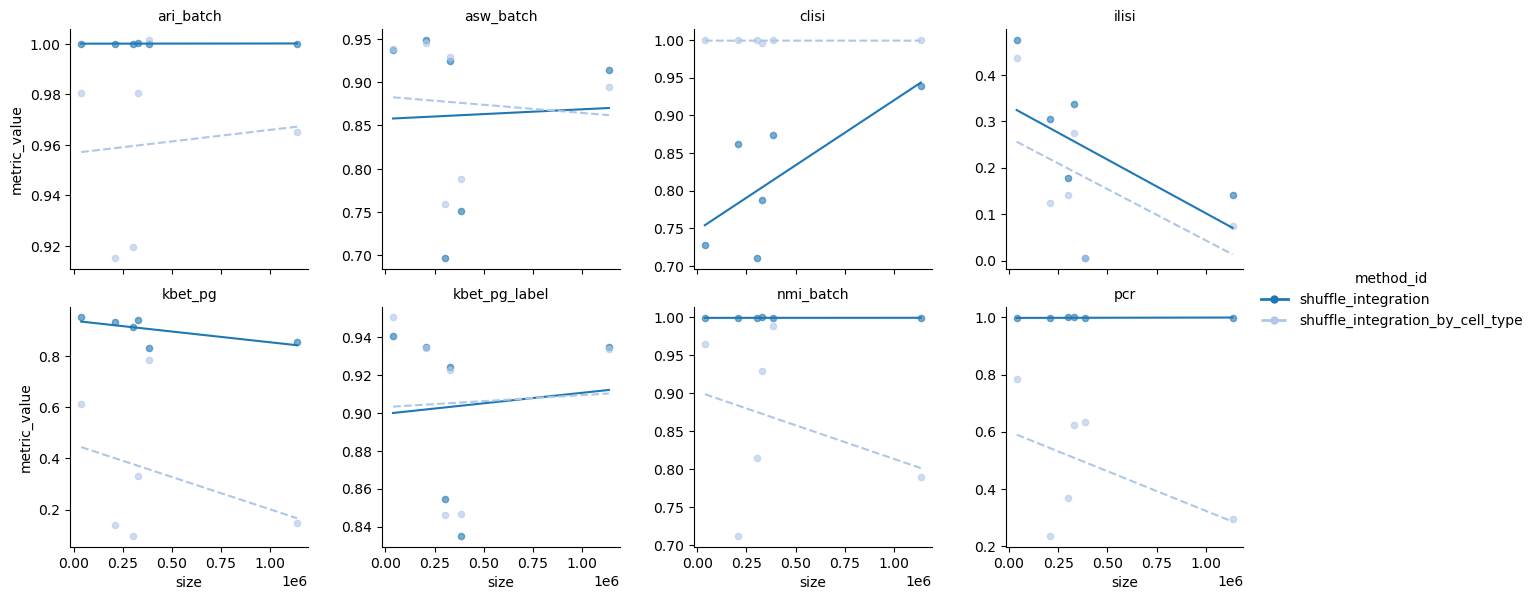

In [84]:
metric_vs_feature_by_method_facet(df.query("control_type == 'negative' and metric_group == 'batch'"), "size")

- consider a different paltette

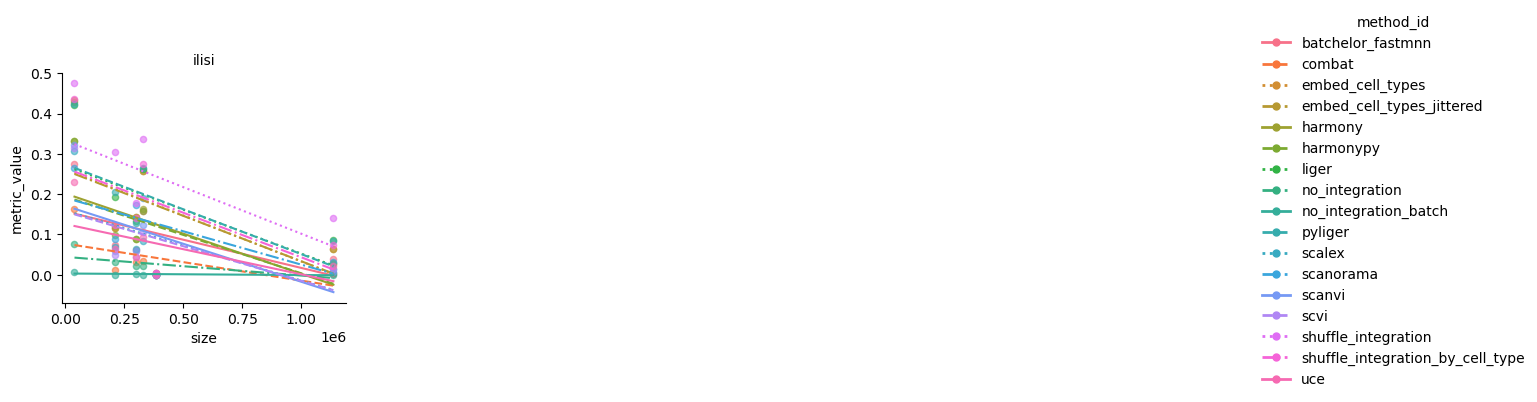

In [153]:
metric_vs_feature_by_method_facet(df.query("metric_id == 'ilisi'"), "size")

In [101]:
df.query("metric_id == 'ilisi'").sort_values("metric_value", ascending=False).head(10)

,dataset_id,method_id,metric_id,metric_value,organism,n_tissues,size,n_genes,n_celltypes,n_batches,batch_imbalance_cv,batch_imbalance_gc,nested_batches,n_samples,n_donors,control_type,control_group,nested_batches_num,metric_type,metric_group
1330,dkd,shuffle_integration,ilisi,0.475200,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,negative,control method,0,batch,batch
1361,dkd,shuffle_integration_by_cell_type,ilisi,0.436953,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,negative,control method,0,batch,batch
512,dkd,embed_cell_types,ilisi,0.434829,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,positive,control method,0,batch,batch
455,dkd,embed_cell_types_jittered,ilisi,0.429159,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,positive,control method,0,batch,batch
1217,dkd,pyliger,ilisi,0.423540,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,non-control,non-control method,0,batch,batch
1400,dkd,liger,ilisi,0.422339,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,non-control,non-control method,0,batch,batch
1016,immune_cell_atlas,shuffle_integration,ilisi,0.337386,Human,17,329762,35469,35,12,0.96,0.460000,No,NaN,12,negative,control method,0,batch,batch
502,dkd,harmony,ilisi,0.332971,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,non-control,non-control method,0,batch,batch
59,dkd,harmonypy,ilisi,0.332744,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,non-control,non-control method,0,batch,batch
701,dkd,scanvi,ilisi,0.321975,Human,1,39176,35469,13,11,0.54,0.266559,No,11.0,11,non-control,non-control method,0,batch,batch


- what is wrong with these two 
- for ilisi -> absolute score is low but still neg-control methods win the others

- workflow
     - plot overall and see if something funky is going on such as negative control-methods above and investigate
     - model and see numbers -> plot interesting metrics => this will be used as the actual model
- since I modeled, correlation doesn't matter here?
    - in some cases the correlation is exactly the same with linear models but it's very limited
    
- condsider starting with simpler model - fixed effects model -> (similar slopes)
    - using r-style formulas: mod = smf.ols(formula='Lottery ~ Literacy + Wealth + Region', data=df) feature + methods
    - if this model is limited for our case - just move on we got no time
    - mixed model is too complex, we don't have enough datapoints -> might be an idea for the next step: all the metrics together

In [155]:
df["method_id"].unique()


array(['embed_cell_types', 'batchelor_fastmnn',
       'embed_cell_types_jittered', 'scanvi', 'liger', 'harmonypy',
       'scalex', 'combat', 'harmony', 'uce', 'shuffle_integration',
       'scvi', 'pyliger', 'no_integration', 'no_integration_batch',
       'scanorama', 'shuffle_integration_by_cell_type'], dtype=object)

In [154]:
model = smf.ols(
    formula="metric_value ~ size + C(method_id)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           metric_value   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     6.464
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           5.41e-15
Time:                        15:17:53   Log-Likelihood:                -473.29
No. Observations:                1496   AIC:                             982.6
Df Residuals:                    1478   BIC:                             1078.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

- R-squared: variability
- coef: beta-coefficient
    - estimated effect
- t: test statistics (coef / std err)
- C(method_id)[T.combat] is compared to the reference mehtod (the 17th method that is not listed in the result: batchelor_fastmnn)
- 


(for mixed effects model)

- beta_feature:
    - On average across all methods, how much does this metric change when size increases by one unit?
    - all very extreamly small..
    - range of size is important -> thus practical_effect, but this concept is from LLM's arse
- p_value:
    - Is the effect of size significantly different from zero?
    - p < 0.05 → effect exists statistically
    - p ≥ 0.05 → effect not detectable
    - if the practical effect is < 0.01, it’s basically negligible. -> check if the threshold makes any sense
    - p < 0.05 but practical_effect trivial → statistically significant but not relevant
- intercept_var:
    - variance of method intercepts, i.e., how much different methods differ in baseline (average) performance.
    - How much do methods differ in this metric, after accounting for dataset size?
- slope_var:
    - random slope variance
    - Do methods differ in how their slope responds to size?
- practical_effect:
    - beta * range of the feature
    - |effect| > 0.1: meaningful
    - 0.05 - 0.1 : moderate
    - <0.05: small
    - <0.01: negligible

- Metrics with meaningful size effects (absolute practical_effect > 0.1):
    - ilisi: -0.18
    - ari: -0.18
    - graph_connectivity: -0.13
    - nmi_batch: -0.12
    - pcr: -0.11
    - asw_label: -0.10
    - kbet_pg: -0.096
    
    These metrics decrease as dataset size gets larger.
- Metrics with moderate effects (0.05–0.1):
    - asw_batch: -0.061
    - isolated_label_f1: -0.076
- Metrics with small or negligible effects (< 0.05):
    - nmi: -0.029
    - isolated_label_asw: -0.032
    - clisi: +0.018
    - ari_batch: +0.007
    - cell_cycle_conservation: +0.003
    
    These metrics are basically size-robust.
- Metrics that slightly increase with size:
    - clisi (+0.018) (batch) → tiny
    - kbet_pg_label (+0.118) (batch) → moderate
    
    batch-separation quality improves slightly with dataset size.

In [148]:
metric_vs_feature_by_method_facet(df.query("metric_id in ['ilisi', 'ari', 'graph_connectivity', 'nmi_batch', 'pcr', 'asw_label', 'kbet_pg', 'kbet_pg_label']"), "size")

TypeError: color_palette() got multiple values for argument 'n_colors'

## vs n_genes

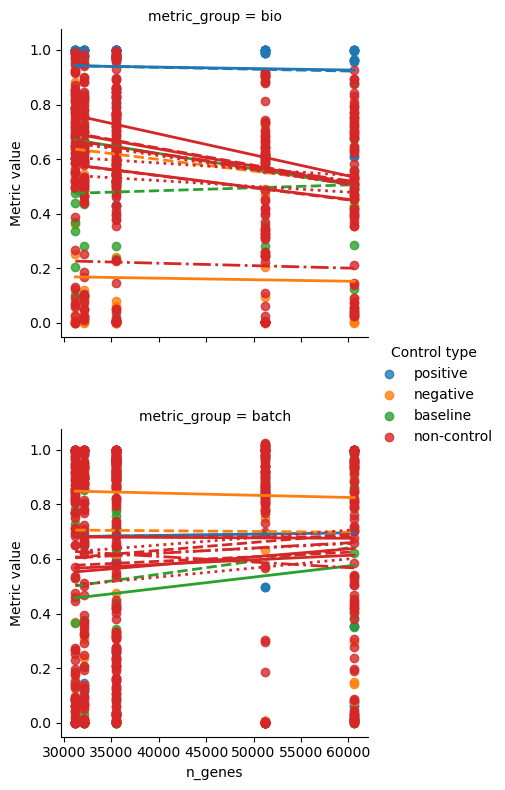

In [82]:
overall_for_feature(df, "n_genes")

- as expected, funky with batch-metric and negative control-methods

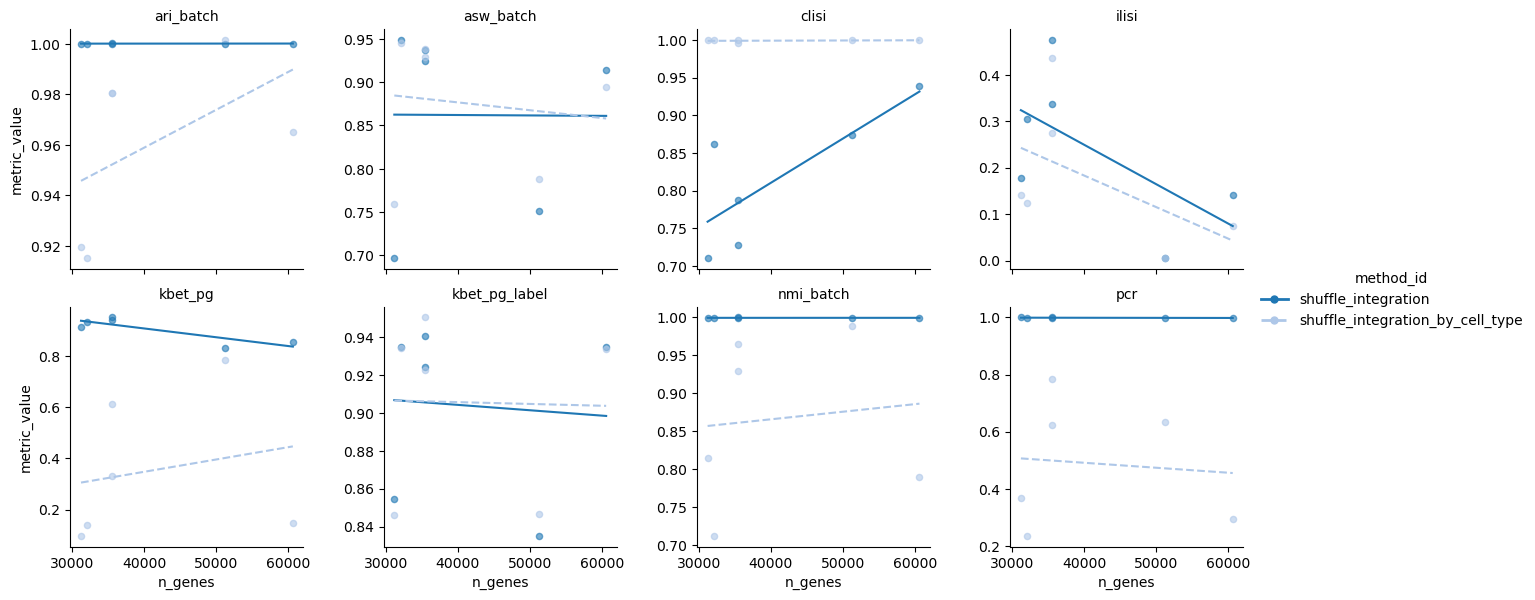

In [85]:
metric_vs_feature_by_method_facet(df.query("control_type == 'negative' and metric_group == 'batch'"), "n_genes")

In [86]:
df_models = fit_model(df, "n_genes")
df_models

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarn

,metric_id,model_type,beta_feature,p_value,intercept_var,slope_var,practical_effect
0,ilisi,random_intercept,-4.951356e-06,1.381937e-07,0.002231,0.0,-0.145590
1,clisi,random_intercept,6.907825e-07,1.171459e-02,0.002623,0.0,0.020312
2,cell_cycle_conservation,random_intercept,-4.079630e-07,6.391467e-01,0.041472,0.0,-0.011996
3,asw_label,random_intercept,-1.309123e-06,9.564630e-03,0.022494,0.0,-0.038493
4,ari,random_intercept,-6.624172e-06,2.721775e-09,0.065438,0.0,-0.194777
5,nmi,random_intercept,-1.203112e-06,5.419245e-02,0.064856,0.0,-0.035376
6,ari_batch,random_intercept,1.420866e-06,4.368487e-05,0.001310,0.0,0.041779
7,nmi_batch,random_intercept,4.270496e-07,6.889780e-01,0.010815,0.0,0.012557
8,kbet_pg,random_intercept,8.870432e-06,1.792715e-03,0.017807,0.0,0.260826
9,graph_connectivity,random_intercept,-2.832860e-06,1.399320e-04,0.059081,0.0,-0.083297


- Metrics that strongly depends on n_genes:
    - kbet_pg_label (+0.28) -> batch
    - kbet_pg (+0.26) -> batch
    - ari (−0.19) -> bio
    - isolated_label_f1 (−0.15) -> bio
    - isolated_label_asw (−0.14) -> bio
    - ilisi (−0.15) -> batch

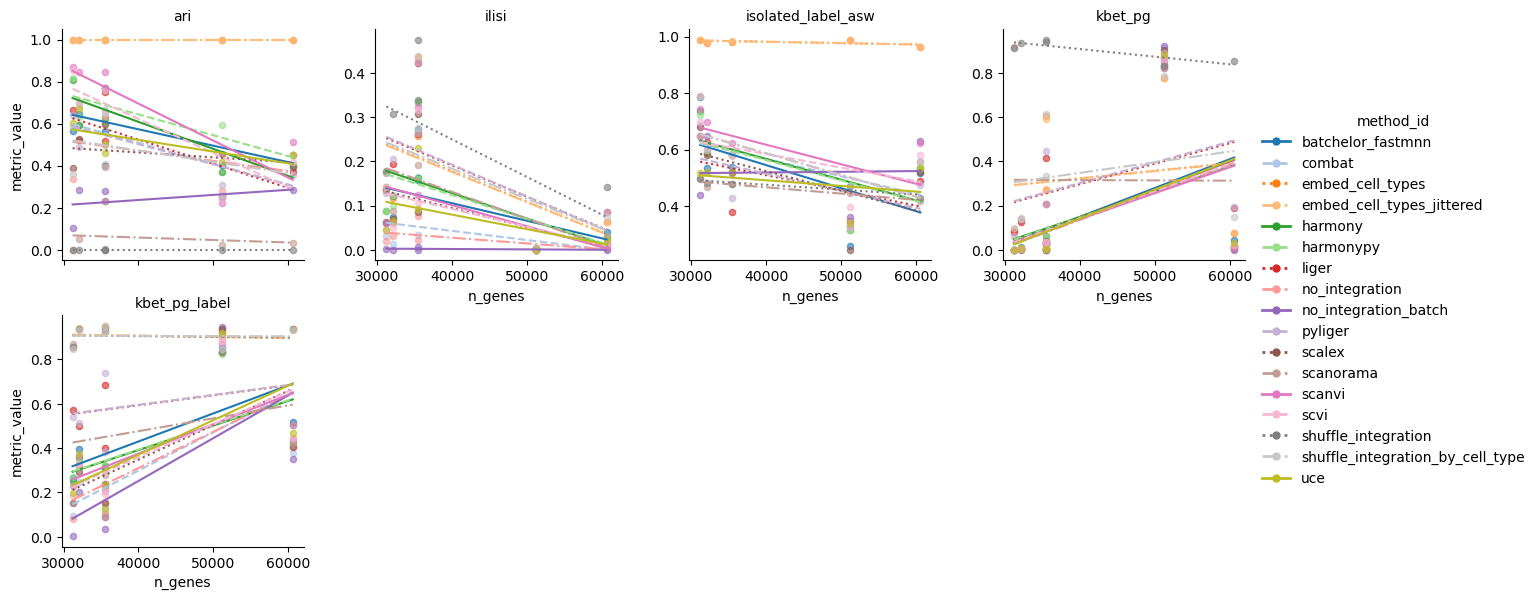

In [92]:
metric_vs_feature_by_method_facet(df.query("metric_id in ['kbet_pg_label', 'kbet_pg', 'ari', 'isolated_label', 'isolated_label_asw', 'ilisi']"), "n_genes")

- bio-metrics show a negative correlation with n_genes
- batch-metrics show a positive correlation with n_genes EXCEPT for ilisi
- I think no_integration_batch is really messing things up.. can I exclude this method

## n_tissues

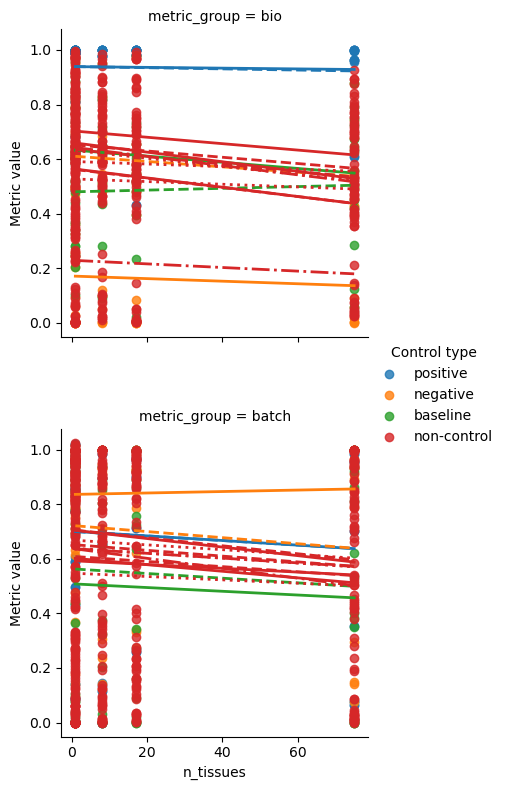

In [94]:
overall_for_feature(df, "n_tissues")

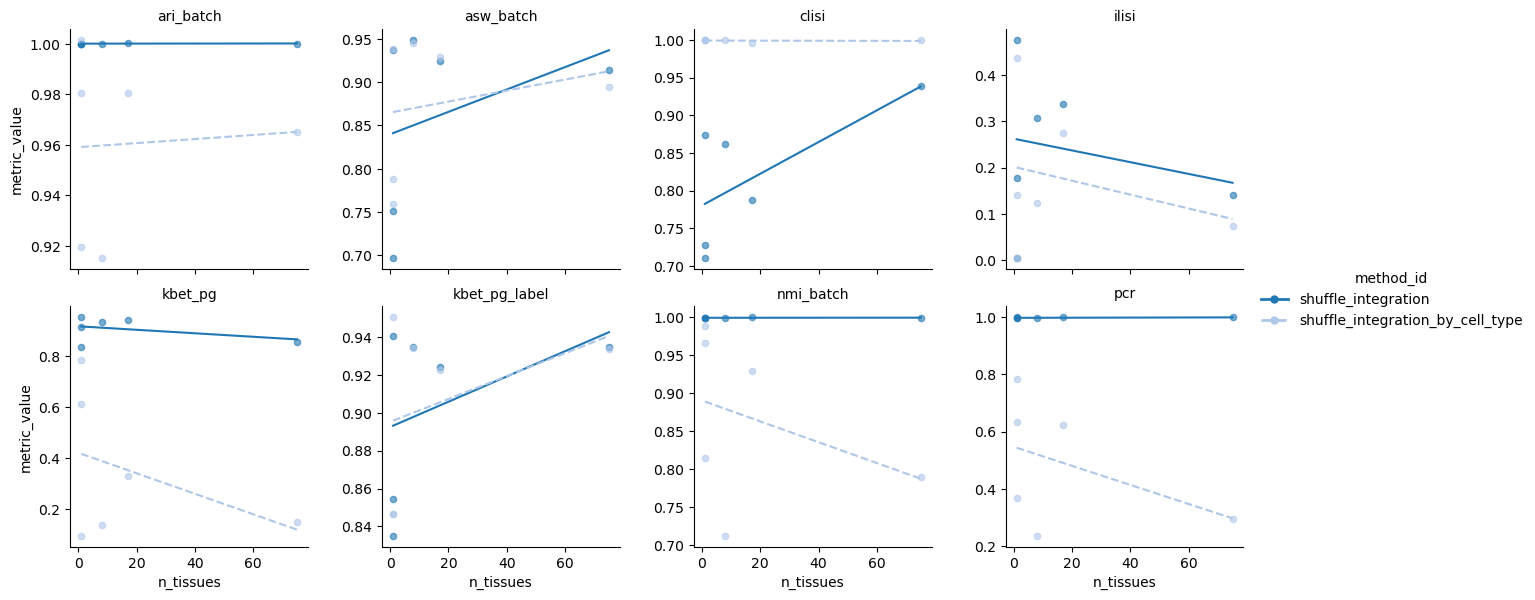

In [96]:
metric_vs_feature_by_method_facet(df.query("control_type == 'negative' and metric_group == 'batch'"), "n_tissues")

In [102]:
df_models = fit_model(df, "n_tissues")
df_models

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packa

,metric_id,model_type,beta_feature,p_value,intercept_var,slope_var,practical_effect
0,ilisi,random_slope,-0.001200,5.484249e-03,0.002793,9.489353e-08,-0.088803
1,clisi,random_intercept,0.000211,6.819798e-02,0.002617,0.000000e+00,0.015610
2,cell_cycle_conservation,random_intercept,0.000269,4.555643e-01,0.041478,0.000000e+00,0.019895
3,asw_label,random_intercept,-0.001346,6.278694e-17,0.022710,0.000000e+00,-0.099573
4,ari,random_intercept,-0.001394,8.470041e-03,0.064646,0.000000e+00,-0.103162
5,nmi,random_intercept,0.000059,8.246127e-01,0.064822,0.000000e+00,0.004344
6,ari_batch,random_slope,-0.000103,5.210407e-01,0.001396,2.101982e-08,-0.007643
7,nmi_batch,random_intercept,-0.001604,8.185835e-05,0.011175,0.000000e+00,-0.118676
8,kbet_pg,random_slope,-0.003487,3.269455e-03,0.016983,1.133040e-07,-0.258009
9,graph_connectivity,random_slope,-0.001563,2.824159e-06,0.053815,6.052841e-07,-0.115693


- Some metrics do support random_slope -> For some metrics, different methods behave differently (method-specific sensitivity) depending on the number of tissues present in the dataset. 
    - batch-metrics (kbet_pg, kbet_pg_label, ari_batch, asw_batch, ilisi) and graph_connectivity, isolated_label_f1 (bio-metric)
    - kbet_pg (−0.258)
    - graph_connectivity (−0.116)
    - and some with small practical effect but still interesting since random_slope
        - kbet_pg_label (-0.007)
        - asw_batch (-0.022)
        - ilisi (-0.088)
        - isolated_label_f1 (−0.098)
        - ari_batch (-0.008)
        
        => visualize these
    
- with random_intercept:
    - asw_label (bio) (-0.100) 
    - ari (bio) (-0.103)
    - nmi_batch (batch) (-0.118)
    

So for metrics with high practical effect:

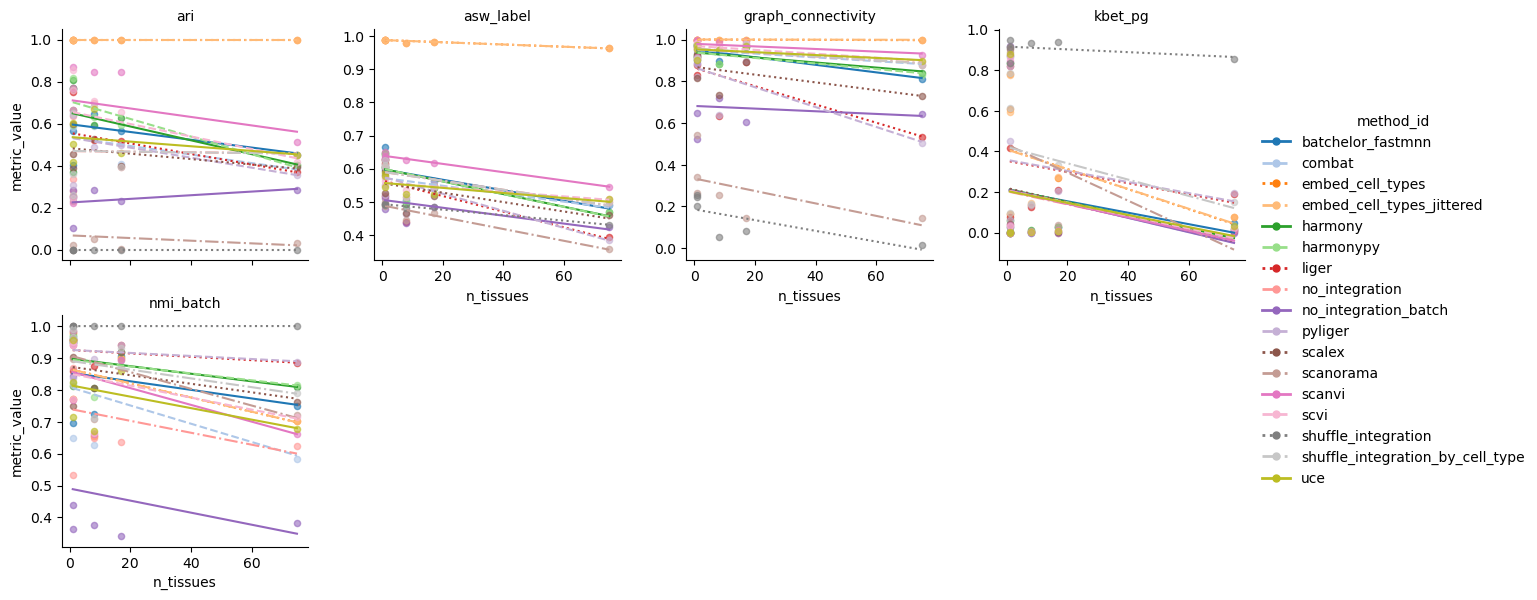

In [117]:
metric_vs_feature_by_method_facet(df.query("metric_id in ['kbet_pg', 'graph_connectivity', 'asw_label', 'ari', 'nmi_batch']"), "n_tissues")

For metrics that have different slopes for methods:

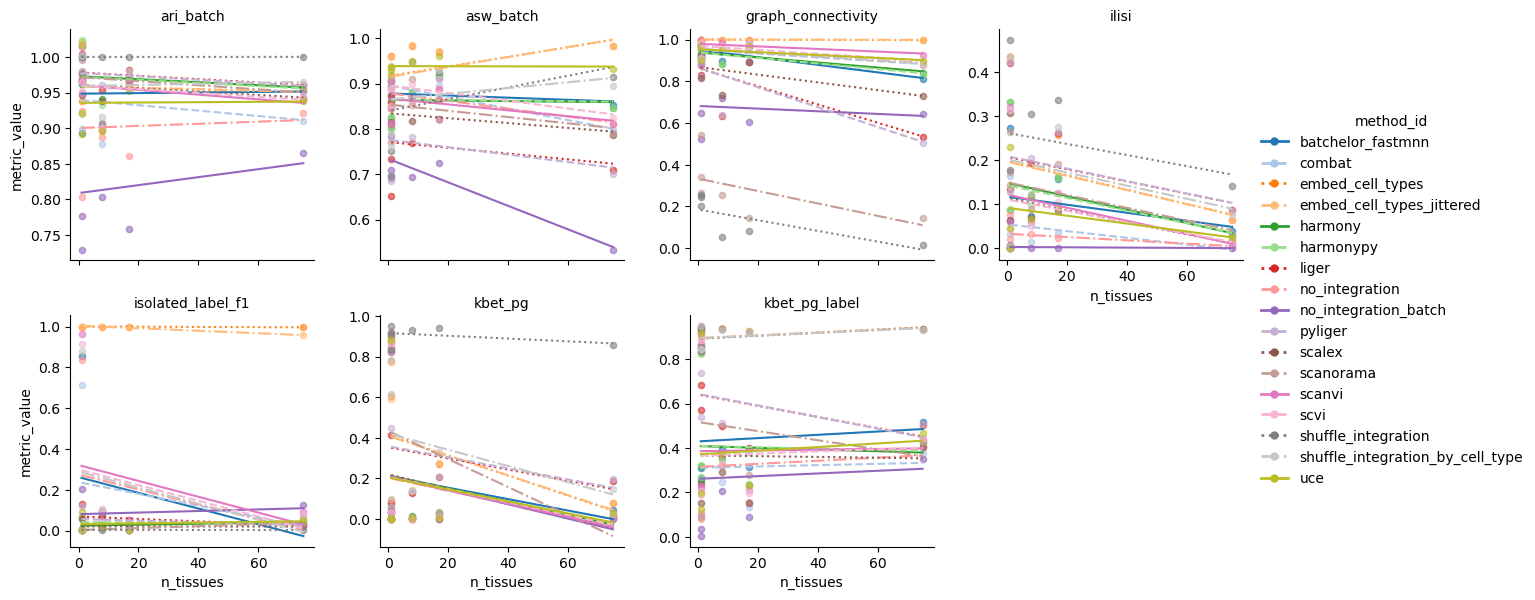

In [118]:
metric_vs_feature_by_method_facet(df.query("metric_id in ['kbet_pg', 'graph_connectivity', 'kbet_pg_label', 'asw_batch', 'ilisi', 'isolated_label_f1', 'ari_batch']"), "n_tissues")

In [139]:
fit, summary = fit_random_slope_model(df.query("metric_id == 'ari_batch'"), "n_tissues")  # for one metric only
df_slopes = extract_method_slopes(fit, feature="n_tissues")
df_slopes.sort_values("slope")

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


,method_id,slope,slope_shift,intercept_shift
14,shuffle_integration,-0.000270,-0.000167,0.0
6,liger,-0.000188,-0.000084,0.0
9,pyliger,-0.000185,-0.000082,0.0
4,harmony,-0.000171,-0.000068,0.0
5,harmonypy,-0.000168,-0.000065,0.0
11,scanorama,-0.000164,-0.000061,0.0
15,shuffle_integration_by_cell_type,-0.000139,-0.000036,0.0
10,scalex,-0.000130,-0.000026,0.0
2,embed_cell_types,-0.000129,-0.000026,0.0
3,embed_cell_types_jittered,-0.000129,-0.000026,0.0


- The warnings are essentially saying 1. slope_var is not 0 but still too small 2. Hessian matrix being not positive definite → curvature is weird / flat / poorly identified.
- So, basically with the slope_var too small (and also the graph above shows no significant difference between the methods) -> random slope model is not reliable

In [145]:
fit, summary = fit_random_slope_model(df.query("metric_id == 'asw_batch'"), "n_tissues")  # for one metric only
df_slopes = extract_method_slopes(fit, feature="n_tissues")
df_slopes.sort_values("slope")

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,method_id,slope,slope_shift,intercept_shift
8,no_integration_batch,-0.001972,-0.001666,0.0
6,liger,-0.001181,-0.000875,0.0
9,pyliger,-0.001178,-0.000872,0.0
10,scalex,-0.000577,-0.000271,0.0
11,scanorama,-0.000434,-0.000128,0.0
12,scanvi,-0.000303,0.000003,0.0
7,no_integration,-0.000243,0.000064,0.0
4,harmony,-0.000197,0.000109,0.0
5,harmonypy,-0.000191,0.000115,0.0
1,combat,-0.000183,0.000123,0.0


In [146]:
fit, summary = fit_random_slope_model(df.query("metric_id == 'graph_connectivity'"), "n_tissues")  # for one metric only
df_slopes = extract_method_slopes(fit, feature="n_tissues")
df_slopes.sort_values("slope")

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,method_id,slope,slope_shift,intercept_shift
14,shuffle_integration,-0.003339,-0.001776,0.0
11,scanorama,-0.003035,-0.001471,0.0
9,pyliger,-0.001982,-0.000419,0.0
6,liger,-0.001933,-0.000369,0.0
8,no_integration_batch,-0.001834,-0.000271,0.0
10,scalex,-0.001551,0.000012,0.0
0,batchelor_fastmnn,-0.001342,0.000222,0.0
5,harmonypy,-0.001303,0.000261,0.0
4,harmony,-0.001286,0.000278,0.0
1,combat,-0.001211,0.000352,0.0


- I guess the slopes don't differ too much but very slightly? Maybe say:
    A mixed model with random slopes suggested modest between-method variability, but the random-effect covariance was nearly singular, indicating that differences in slopes were small.

- kbet_pg, nmi_batch (batch), graph_connectivity, asw_label, ari (bio) show a negative correlation with n_tissues

## vs n_celltypes

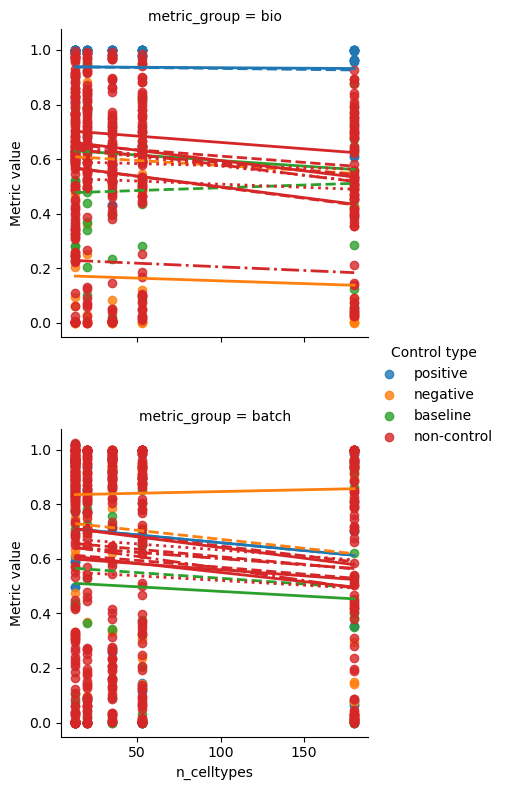

In [119]:
overall_for_feature(df, "n_celltypes")

In [120]:
df_models = fit_model(df, "n_celltypes")
df_models

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarn

,metric_id,model_type,beta_feature,p_value,intercept_var,slope_var,practical_effect
0,ilisi,random_intercept,-0.000609,1.463882e-03,0.001891,0.000000e+00,-0.101776
1,clisi,random_intercept,0.000104,4.488234e-02,0.002619,0.000000e+00,0.017393
2,cell_cycle_conservation,random_intercept,0.000186,2.509955e-01,0.041498,0.000000e+00,0.030992
3,asw_label,random_slope,-0.000655,9.691952e-01,0.037093,4.890956e-03,-0.109390
4,ari,random_slope,-0.000499,3.515429e-02,0.077105,3.749504e-09,-0.083320
5,nmi,random_slope,0.000076,9.981055e-01,0.128913,1.751954e-02,0.012730
6,ari_batch,random_intercept,-0.000098,1.635667e-01,0.001267,0.000000e+00,-0.016374
7,nmi_batch,random_intercept,-0.000900,2.274144e-07,0.011376,0.000000e+00,-0.150319
8,kbet_pg,random_intercept,-0.001748,9.255023e-04,0.018020,0.000000e+00,-0.291974
9,graph_connectivity,random_slope,-0.000756,9.790161e-01,0.100520,1.405362e-02,-0.126294


- Meaningful random slopes:
    - asw_label (0.00489)
    - nmi (0.0175)
    - graph_connectivity (0.0140)
- random intercept (practical effect):
    - kbet_pg: −0.292 → very sensitive
    - nmi_batch: −0.150
    - asw_label: −0.109
    - pcr: −0.110
    - ilisi: −0.102
    - graph_connectivity: −0.126

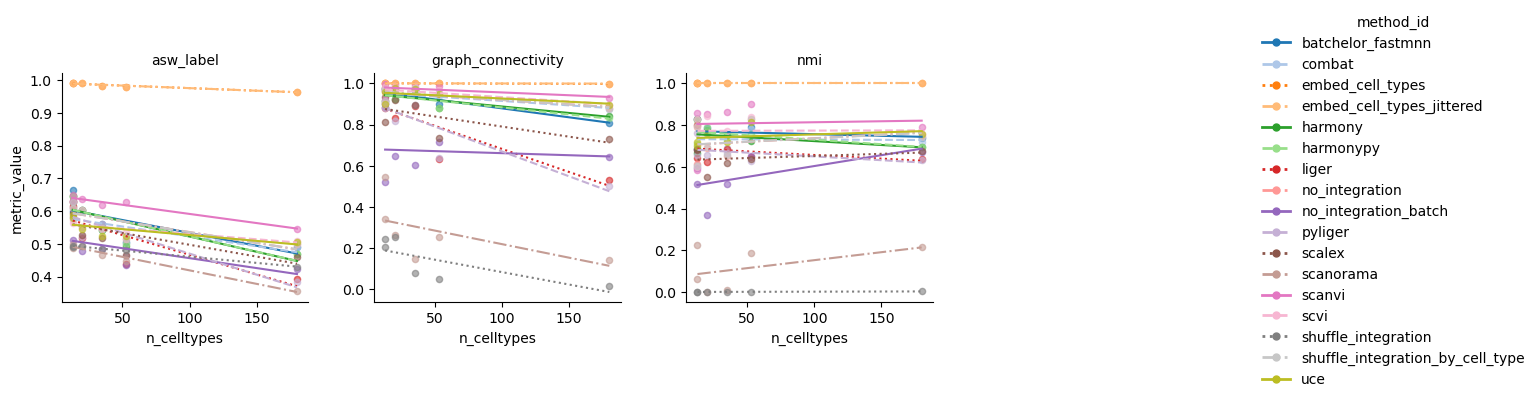

In [123]:
metric_vs_feature_by_method_facet(df.query("metric_id in ['asw_label', 'nmi', 'graph_connectivity']"), "n_celltypes")

- The slopes look the same.. let's check:

In [130]:
# centering n_celltypes because of the warnings
df["n_celltypes_centered"] = df["n_celltypes"] - df["n_celltypes"].mean()

In [142]:
fit, summary = fit_random_slope_model(df.query("metric_id == 'asw_label'"), "n_celltypes_centered")  # for one metric only
df_slopes = extract_method_slopes(fit, feature="n_celltypes_centered")
df_slopes.sort_values("slope")

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarn

,method_id,slope,slope_shift,intercept_shift
9,pyliger,-0.001285,-0.000630,0.0
6,liger,-0.001200,-0.000545,0.0
4,harmony,-0.000933,-0.000278,0.0
5,harmonypy,-0.000932,-0.000277,0.0
11,scanorama,-0.000824,-0.000169,0.0
0,batchelor_fastmnn,-0.000785,-0.000130,0.0
10,scalex,-0.000720,-0.000065,0.0
15,shuffle_integration_by_cell_type,-0.000658,-0.000003,0.0
7,no_integration,-0.000658,-0.000003,0.0
8,no_integration_batch,-0.000606,0.000049,0.0


In [143]:
fit, summary = fit_random_slope_model(df.query("metric_id == 'nmi'"), "n_celltypes_centered")  # for one metric only
df_slopes = extract_method_slopes(fit, feature="n_celltypes_centered")
df_slopes.sort_values("slope")

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarn

,method_id,slope,slope_shift,intercept_shift
5,harmonypy,-4.319476e-04,-0.000508,0.0
4,harmony,-3.715531e-04,-0.000448,0.0
9,pyliger,-3.623755e-04,-0.000439,0.0
6,liger,-3.461675e-04,-0.000422,0.0
0,batchelor_fastmnn,-1.590079e-04,-0.000235,0.0
1,combat,-2.415506e-05,-0.000100,0.0
3,embed_cell_types_jittered,-6.613972e-07,-0.000077,0.0
2,embed_cell_types,-6.190989e-07,-0.000077,0.0
13,scvi,1.435108e-05,-0.000062,0.0
14,shuffle_integration,1.571139e-05,-0.000061,0.0


In [144]:
fit, summary = fit_random_slope_model(df.query("metric_id == 'graph_connectivity'"), "n_celltypes_centered")  # for one metric only
df_slopes = extract_method_slopes(fit, feature="n_celltypes_centered")
df_slopes.sort_values("slope")

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarn

,method_id,slope,slope_shift,intercept_shift
9,pyliger,-0.002413,-0.001657,0.0
6,liger,-0.002240,-0.001483,0.0
11,scanorama,-0.001314,-0.000558,0.0
14,shuffle_integration,-0.001205,-0.000449,0.0
10,scalex,-0.000980,-0.000224,0.0
0,batchelor_fastmnn,-0.000870,-0.000113,0.0
5,harmonypy,-0.000679,0.000077,0.0
4,harmony,-0.000629,0.000128,0.0
15,shuffle_integration_by_cell_type,-0.000444,0.000313,0.0
1,combat,-0.000428,0.000328,0.0


- The warnings are saying it didn't fit well, I'll have to not consider the random slope model
- “The random-slope model for NMI vs n_celltypes failed to converge reliably; we therefore do not interpret method-specific slopes and instead rely on a random-intercept model (common slope across methods).”